# Supervised Learning Model Evaluation Lab

Complete the exercises below to solidify your knowledge and understanding of supervised learning model evaluation.

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split

## Regression Model Evaluation

In [2]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
data = pd.read_csv('housing.csv', header=None, delimiter=r"\s+", names=column_names)

In [3]:
"""
CRIM - per capita crime rate by town
ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS - proportion of non-retail business acres per town.
CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
NOX - nitric oxides concentration (parts per 10 million)
RM - average number of rooms per dwelling
AGE - proportion of owner-occupied units built prior to 1940
DIS - weighted distances to five Boston employment centres
RAD - index of accessibility to radial highways
TAX - full-value property-tax rate per $10,000
PTRATIO - pupil-teacher ratio by town
B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
LSTAT - % lower status of the population
MEDV - Median value of owner-occupied homes in $1000's"""

"\nCRIM - per capita crime rate by town\nZN - proportion of residential land zoned for lots over 25,000 sq.ft.\nINDUS - proportion of non-retail business acres per town.\nCHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)\nNOX - nitric oxides concentration (parts per 10 million)\nRM - average number of rooms per dwelling\nAGE - proportion of owner-occupied units built prior to 1940\nDIS - weighted distances to five Boston employment centres\nRAD - index of accessibility to radial highways\nTAX - full-value property-tax rate per $10,000\nPTRATIO - pupil-teacher ratio by town\nB - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town\nLSTAT - % lower status of the population\nMEDV - Median value of owner-occupied homes in $1000's"

In [3]:
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


## 1. Split this data set into training (80%) and testing (20%) sets.

The `MEDV` field represents the median value of owner-occupied homes (in $1000's) and is the target variable that we will want to predict.

In [4]:
# Your code here :
X = data.drop(columns=["MEDV"])
y = data["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## 2. Train a `LinearRegression` model on this data set and generate predictions on both the training and the testing set.

In [5]:
# Your code here :
from sklearn.linear_model import LinearRegression

In [6]:
lr = LinearRegression()
lr

LinearRegression()

In [7]:
lr.fit(X_train, y_train)

LinearRegression()

In [8]:
random_house = X_test.sample()

In [9]:
random_house

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
388,14.3337,0.0,18.1,0,0.7,4.88,100.0,1.5895,24,666.0,20.2,372.92,30.62


In [10]:
y_test.loc[312]

np.float64(19.4)

In [11]:
lr.predict(random_house)

array([5.79472718])

In [12]:
lr.score(X_test, y_test)

0.6687594935356291

## 3. Calculate and print R-squared for both the training and the testing set.

In [13]:
from sklearn.metrics import r2_score

In [14]:
y_pred_test = lr.predict(X_test)
y_pred_train = lr.predict(X_train)

In [15]:
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print("R² (train):", r2_train)
print("R² (test):", r2_test)

R² (train): 0.7508856358979672
R² (test): 0.6687594935356291


## 4. Calculate and print mean squared error for both the training and the testing set.

In [16]:
from sklearn.metrics import mean_squared_error

In [17]:
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

In [18]:
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

In [19]:
mse_train

21.641412753226316

In [20]:
mse_test

24.291119474973726

## 5. Calculate and print mean absolute error for both the training and the testing set.

In [21]:
from sklearn.metrics import mean_absolute_error

In [22]:
y_pred_test = lr.predict(X_test)
y_pred_train = lr.predict(X_train)

In [23]:
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

In [24]:
mae_train

3.31477162678323

In [25]:
mae_test

3.189091965887875

## Classification Model Evaluation

In [29]:
from sklearn.datasets import load_iris
data = load_iris()

In [36]:
data.columns

AttributeError: columns

In [57]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [37]:
column_names = data.feature_names

In [38]:
df = pd.DataFrame(data['data'],columns=column_names)

In [39]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [40]:
target = pd.DataFrame(data.target)

In [41]:
target

,0
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [42]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [43]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## 6. Split this data set into training (80%) and testing (20%) sets.

The `class` field represents the type of flower and is the target variable that we will want to predict.

In [44]:
# Split: 80% training, 20% testing
# X = df. X is from the housing.csv
# y = target

X_train, X_test, y_train, y_test = train_test_split(df, target, test_size = 0.2, random_state = 42)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 120
Testing set size: 30


In [80]:
# X = df. X is from the housing.csv
# y = target

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48


In [116]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


## 7. Train a `LogisticRegression` model on this data set and generate predictions on both the training and the testing set.

In [45]:
# Your code here :
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

In [46]:
LogisticRegression()

LogisticRegression()

In [47]:
print("Training accuracy:", log_reg.score(X_train, y_train))
print("Testing accuracy:", log_reg.score(X_test, y_test))

Training accuracy: 0.975
Testing accuracy: 1.0


## 8. Calculate and print the accuracy score for both the training and the testing set.

In [48]:
# Your code here :
print("Accuracy Score of the Training set is: ", log_reg.score(X_train, y_train))
print("Accuracy Score of the Training set is: ", log_reg.score(X_test, y_test))

Accuracy Score of the Training set is:  0.975
Accuracy Score of the Training set is:  1.0


## 9. Calculate and print the balanced accuracy score for both the training and the testing set.

In [49]:
from sklearn.metrics import balanced_accuracy_score

In [50]:
# Predictions
y_pred_train = log_reg.predict(X_train)
y_pred_test = log_reg.predict(X_test)

# Balanced accuracy
bal_acc_train = balanced_accuracy_score(y_train, y_pred_train)
bal_acc_test = balanced_accuracy_score(y_test, y_pred_test)

print("Balanced Accuracy (train):", bal_acc_train)
print("Balanced Accuracy (test):", bal_acc_test)


Balanced Accuracy (train): 0.975609756097561
Balanced Accuracy (test): 1.0


## 10. Calculate and print the precision score for both the training and the testing set.

In [51]:
from sklearn.metrics import precision_score

In [52]:
# Predictions
y_pred_train = log_reg.predict(X_train)
y_pred_test = log_reg.predict(X_test)

# Precision scores
# Macro because unweighted mean across classes (treats all classes equally), as they're already balanced.
prec_train = precision_score(y_train, y_pred_train, average="macro") 
prec_test = precision_score(y_test, y_pred_test, average="macro")

print("Precision (train):", prec_train)
print("Precision (test):", prec_test)

Precision (train): 0.9761904761904763
Precision (test): 1.0


## 11. Calculate and print the recall score for both the training and the testing set.

In [53]:
from sklearn.metrics import recall_score

# Predictions
y_pred_train = log_reg.predict(X_train)
y_pred_test = log_reg.predict(X_test)

# Training metrics
rec_train = recall_score(y_train, y_pred_train, average="macro")

# Testing metrics
rec_test = recall_score(y_test, y_pred_test, average="macro")

print("Training metrics:")
print("  Recall   :", rec_train)

print("\nTesting metrics:")
print("  Recall   :", rec_test)


Training metrics:
  Recall   : 0.975609756097561

Testing metrics:
  Recall   : 1.0


## 12. Calculate and print the F1 score for both the training and the testing set.

In [ ]:
# F1 score is harmonic mean, finds a balance between precision and recall

In [54]:
from sklearn.metrics import f1_score

In [55]:
y_pred_train = log_reg.predict(X_train)
y_pred_test = log_reg.predict(X_test)

In [56]:
# Training metrics
f1_train = f1_score(y_train, y_pred_train, average="macro")

In [57]:
# Testing metrics
f1_test = f1_score(y_test, y_pred_test, average="macro")

In [58]:
print("Training metrics:")
print("  F1-score :", f1_train)

Training metrics:
  F1-score : 0.974996093139553


In [59]:
print("\nTesting metrics:")
print("  F1-score :", f1_test)


Testing metrics:
  F1-score : 1.0


## 13. Generate confusion matrices for both the training and the testing set.

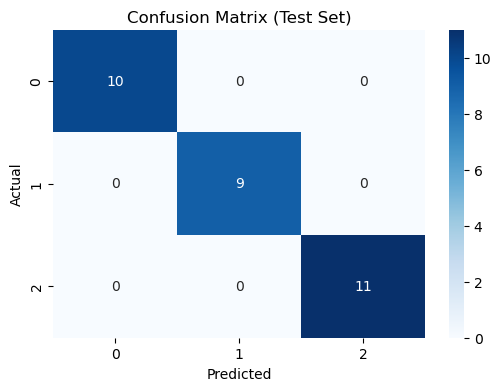

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predictions on test set
y_pred_test = log_reg.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test, labels=log_reg.classes_)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=log_reg.classes_,
            yticklabels=log_reg.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.show()

## Bonus: For each of the data sets in this lab, try training with some of the other models you have learned about, recalculate the evaluation metrics, and compare to determine which models perform best on each data set.

In [26]:
# Have fun here !
# KNN - change n_neighbors

In [61]:
from sklearn.neighbors import KNeighborsClassifier

In [62]:
knn = KNeighborsClassifier()

In [63]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [64]:
random_test = X_test.sample()
random_test

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
141,6.9,3.1,5.1,2.3


In [65]:
knn.predict(random_test)

array([2])

In [66]:
knn.score(X_test, y_test)

1.0

In [ ]:
# Can also do Decision Tree